#### Name: Doaa Hisham Hamdan
#### ID: 2320224203
#### Ass2_ML

In [1]:
import io
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


In [2]:
uploaded = files.upload()

def load_uploaded_marketing_file(uploaded_dict):
    file_name = next(iter(uploaded_dict))
    content = uploaded_dict[file_name]

    separators = ["\t", ";", ","]
    best_df = None
    best_sep = None

    for sep in separators:
        try:
            temp_df = pd.read_csv(io.BytesIO(content), sep=sep)
            if best_df is None or temp_df.shape[1] > best_df.shape[1]:
                best_df = temp_df
                best_sep = sep
        except Exception:
            pass

    if best_df is None:
        raise ValueError("Could not read the uploaded file. Please upload marketing_campaign.csv.")

    best_df.columns = best_df.columns.str.strip()
    print(f"Loaded file: {file_name}")
    print(f"Detected separator: {repr(best_sep)}")
    print(f"Shape: {best_df.shape}")
    return best_df

df_raw = load_uploaded_marketing_file(uploaded)
df_raw.head()


Saving marketing_campaign.csv to marketing_campaign.csv
Loaded file: marketing_campaign.csv
Detected separator: '\t'
Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
print("Missing values before preprocessing:")
display(df_raw.isnull().sum())

Missing values before preprocessing:


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [4]:
SPENDING_COLS = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

def preprocess_customer_data(df, current_year=None):
    df = df.copy()
    df.columns = df.columns.str.strip()

    if current_year is None:
        current_year = datetime.now().year

    numeric_cols = [
        "Income", "Year_Birth", "Kidhome", "Teenhome", "Recency",
        "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
        "NumStorePurchases", "NumWebVisitsMonth",
        "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
        "AcceptedCmp4", "AcceptedCmp5", "Complain", "Response"
    ] + SPENDING_COLS

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Income"] = df["Income"].fillna(df["Income"].median())
    df["Age"] = current_year - df["Year_Birth"]

    for col in SPENDING_COLS:
        df[col] = df[col].fillna(0)

    df["TotalSpending"] = df[SPENDING_COLS].sum(axis=1)
    df["TotalChildren"] = df["Kidhome"].fillna(0) + df["Teenhome"].fillna(0)

    df = df[(df["Age"].between(18, 100)) & (df["Income"] > 0)]

    education_map = {
        "Basic": 0, "Graduation": 1,
        "2n Cycle": 2, "Master": 2, "PhD": 3
    }

    df["Education_encoded"] = df["Education"].map(education_map)
    df["Education_encoded"] = df["Education_encoded"].fillna(df["Education_encoded"].median())

    top4 = df["Marital_Status"].value_counts().nlargest(4).index

    df["Marital_Status_Grouped"] = df["Marital_Status"].where(
        df["Marital_Status"].isin(top4),
        "Other"
    )

    df = pd.concat([
        df,
        pd.get_dummies(df["Marital_Status_Grouped"], prefix="Marital", dtype=int)
    ], axis=1)

    return df, df["Income"].median(), list(top4)

df, income_median, top4_marital = preprocess_customer_data(df_raw)

display(df.head())
df.shape


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Education_encoded,Marital_Status_Grouped,Marital_Divorced,Marital_Married,Marital_Other,Marital_Single,Marital_Together
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,1617,0,1,Single,0,0,0,1,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,27,2,1,Single,0,0,0,1,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,776,0,1,Together,0,0,0,0,1
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,53,1,1,Together,0,0,0,0,1
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,422,1,3,Married,0,1,0,0,0


(2237, 39)

In [5]:
print("Missing values after preprocessing:")
display(df.isnull().sum())

Missing values after preprocessing:


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


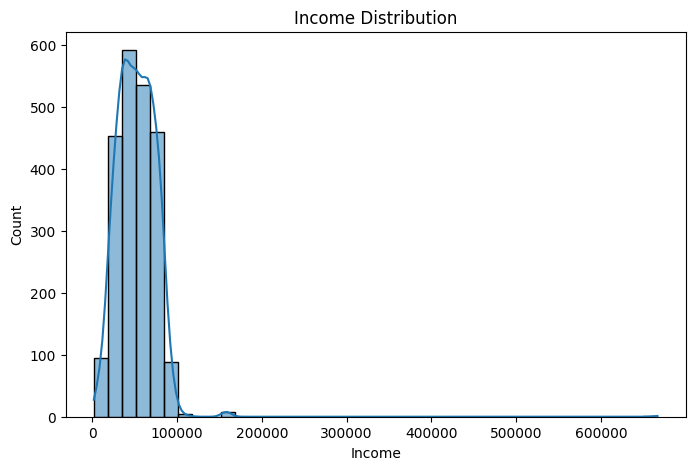

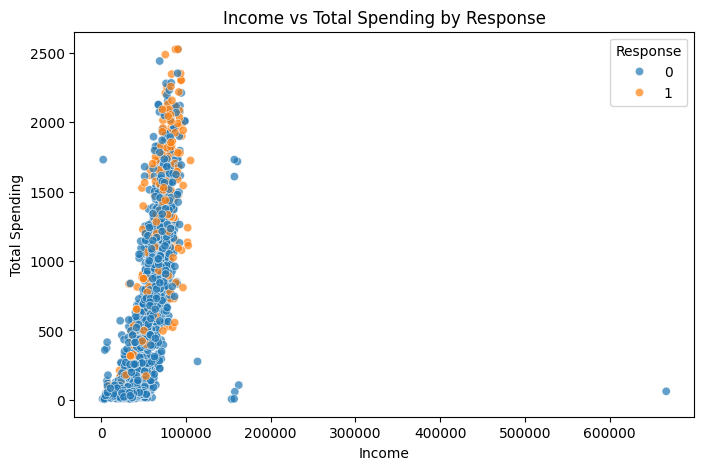

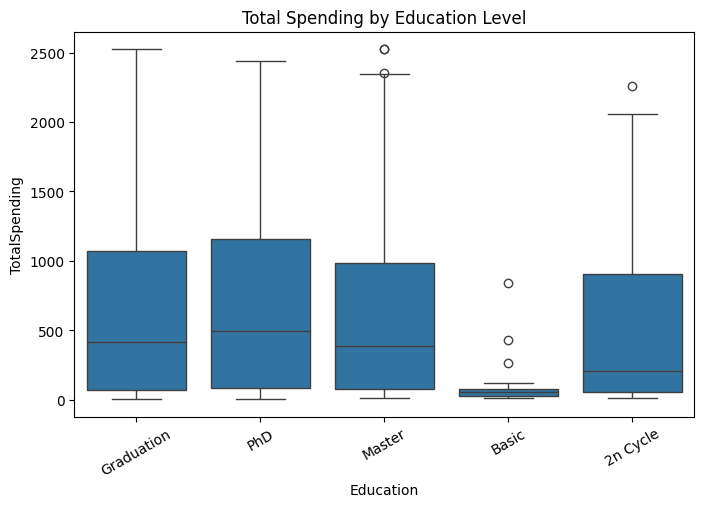

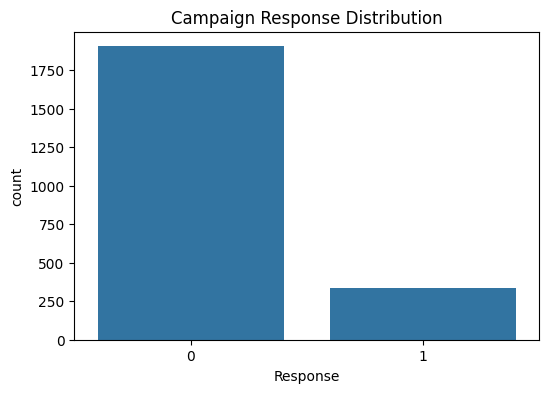

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Income"], bins=40, kde=True)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Income", y="TotalSpending", hue="Response", alpha=0.7)
plt.title("Income vs Total Spending by Response")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Education", y="TotalSpending")
plt.title("Total Spending by Education Level")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Response")
plt.title("Campaign Response Distribution")
plt.show()

In [7]:
marital_cols = [c for c in df.columns if c.startswith("Marital_")]

base_feature_cols = [
    "Income", "Age", "TotalChildren", "Education_encoded",
    "Kidhome", "Teenhome", "Recency",
    "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
    "NumStorePurchases", "NumWebVisitsMonth",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5", "Complain"
] + marital_cols

base_feature_cols = [c for c in base_feature_cols if c in df.columns]

regression_features = base_feature_cols
classification_features = base_feature_cols + ["TotalSpending"]


In [8]:
X_reg = df[regression_features].copy()
X_reg = X_reg.apply(pd.to_numeric, errors="coerce").fillna(0)

y_reg = df["TotalSpending"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE
)

reg_scaler = StandardScaler()
X_train_reg_scaled = reg_scaler.fit_transform(X_train_reg)
X_test_reg_scaled = reg_scaler.transform(X_test_reg)

regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
}

results = []

for name, model in regression_models.items():
    model.fit(X_train_reg_scaled, y_train_reg)
    y_pred = model.predict(X_test_reg_scaled)

    results.append({
        "Model": name,
        "MSE": mean_squared_error(y_test_reg, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred)),
        "R2": r2_score(y_test_reg, y_pred)
    })

regression_results_df = pd.DataFrame(results).sort_values("RMSE")
display(regression_results_df)

best_reg_model = regression_results_df.iloc[0]["Model"]
best_reg_model

,Model,MSE,RMSE,R2
2,Decision Tree,59744.715910,244.427322,0.842725
1,Ridge Regression,70359.612465,265.253864,0.814782
0,Linear Regression,70369.605109,265.272700,0.814756


'Decision Tree'

In [9]:
class_distribution = df["Response"].value_counts().sort_index()

display(pd.DataFrame({
    "Count": class_distribution,
    "Percentage": (class_distribution / class_distribution.sum() * 100).round(2)
}))

,Count,Percentage
Response,,
0,1903,85.07
1,334,14.93


              precision    recall  f1-score   support

           0      0.953     0.795     0.867       381
           1      0.400     0.776     0.528        67

    accuracy                          0.792       448
   macro avg      0.676     0.786     0.697       448
weighted avg      0.870     0.792     0.816       448



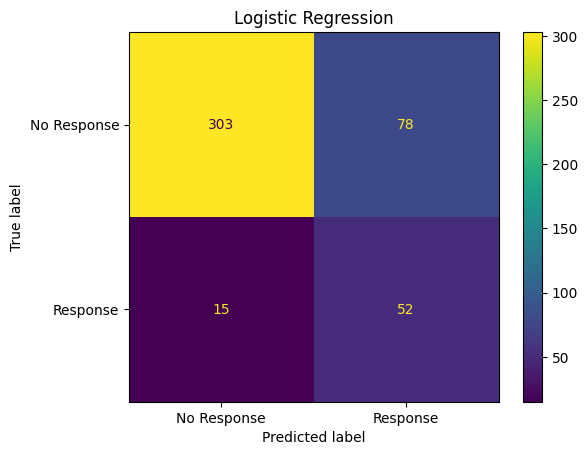

              precision    recall  f1-score   support

           0      0.898     0.969     0.932       381
           1      0.676     0.373     0.481        67

    accuracy                          0.879       448
   macro avg      0.787     0.671     0.706       448
weighted avg      0.865     0.879     0.864       448



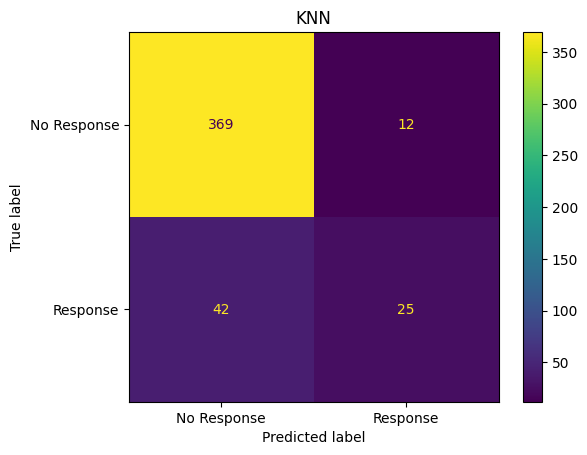

              precision    recall  f1-score   support

           0      0.899     0.976     0.936       381
           1      0.735     0.373     0.495        67

    accuracy                          0.886       448
   macro avg      0.817     0.675     0.715       448
weighted avg      0.874     0.886     0.870       448



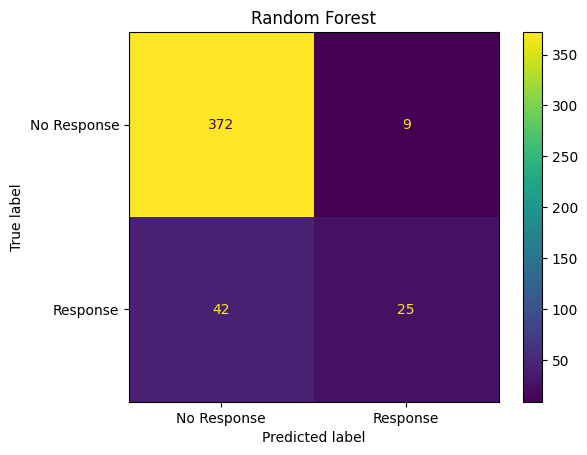

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.792411,0.400000,0.776119,0.527919
2,Random Forest,0.886161,0.735294,0.373134,0.495050
1,KNN,0.879464,0.675676,0.373134,0.480769


'Logistic Regression'

In [10]:
X_clf = df[classification_features].copy()
X_clf = X_clf.apply(pd.to_numeric, errors="coerce").fillna(0)

y_clf = df["Response"].astype(int)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
X_test_scaled = scaler.transform(X_test_clf)

models = {
    "Logistic Regression": {
        "model": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
        "scaled": True
    },
    "KNN": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "scaled": True
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        "scaled": False
    }
}

results = []

for name, cfg in models.items():
    X_tr = X_train_scaled if cfg["scaled"] else X_train_clf
    X_te = X_test_scaled if cfg["scaled"] else X_test_clf

    model = cfg["model"]
    model.fit(X_tr, y_train_clf)
    y_pred = model.predict(X_te)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_clf, y_pred),
        "Precision": precision_score(y_test_clf, y_pred, zero_division=0),
        "Recall": recall_score(y_test_clf, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test_clf, y_pred, zero_division=0)
    })

    print(classification_report(y_test_clf, y_pred, digits=3, zero_division=0))

    cm = confusion_matrix(y_test_clf, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Response", "Response"]).plot()
    plt.title(name)
    plt.show()

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
display(results_df)

best_model = results_df.iloc[0]["Model"]
best_model

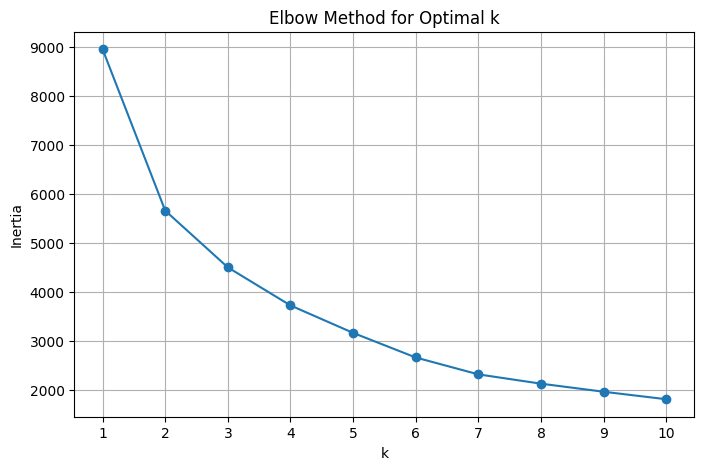

In [11]:
cluster_features = ["TotalSpending", "Income", "Age", "TotalChildren"]

cluster_data = df[cluster_features].copy()
cluster_data = cluster_data.apply(pd.to_numeric, errors="coerce").dropna()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()


In [12]:
chosen_k = 3

kmeans_final = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(cluster_scaled)

df.loc[cluster_data.index, "Cluster"] = cluster_labels
df["Cluster"] = df["Cluster"].astype("Int64")

display(df["Cluster"].value_counts().sort_index())
display(df[cluster_features + ["Cluster"]].head())

,count
Cluster,
0,710
1,796
2,731


,TotalSpending,Income,Age,TotalChildren,Cluster
0,1617,58138.0,69,0,1
1,27,46344.0,72,2,0
2,776,71613.0,61,0,1
3,53,26646.0,42,1,2
4,422,58293.0,45,1,2


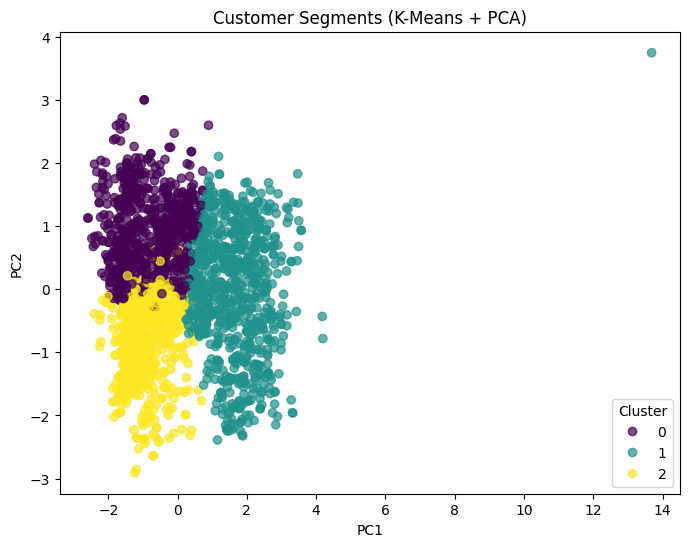

In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(cluster_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_components[:, 0],
    "PC2": pca_components[:, 1],
    "Cluster": cluster_labels
})

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    alpha=0.7
)

plt.title("Customer Segments (K-Means + PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

In [14]:
cluster_profile = (
    df.loc[cluster_data.index]
    .groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)

In [15]:
def level_label(value, series):
    q1 = series.quantile(0.33)
    q2 = series.quantile(0.66)

    if value <= q1:
        return "low"
    elif value >= q2:
        return "high"
    return "medium"


segment_summary = []

for cluster_id, row in cluster_profile.iterrows():
    segment_summary.append({
        "Cluster": cluster_id,
        "Income_Level": level_label(row["Income"], cluster_profile["Income"]),
        "Spending_Level": level_label(row["TotalSpending"], cluster_profile["TotalSpending"]),
        "Age_Group": "younger" if row["Age"] < cluster_profile["Age"].median() else "older",
        "Children_Level": (
            "few/no children" if row["TotalChildren"] < 0.5
            else "some children" if row["TotalChildren"] < 1.5
            else "more children"
        )
    })

segment_df = pd.DataFrame(segment_summary)
display(segment_df)

,Cluster,Income_Level,Spending_Level,Age_Group,Children_Level
0,0,medium,medium,older,more children
1,1,high,high,older,few/no children
2,2,low,low,younger,some children
